In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from tqdm.notebook import tqdm
from syn2real_dataset import Syn2RealDataset
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import numpy as np
import math
import os

# Add ../ as a directory to import from
import sys
sys.path.append('../')


In [2]:
# Check if CUDA is available and set the default device to GPU if it is
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"

# Export DISPLAY to 10.0
os.environ["DISPLAY"] = ":12.0"

In [9]:
from torch.utils.data import DataLoader
from plant_dataset import PlantDataset 
if 0:
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406, 0.5], std=[0.229, 0.224, 0.225, 0.5])
    ])
else:
    transform = transforms.Compose([
        #transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5, 0.5])
        #transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5,  0.5])
    ])


from plant_tokenizer import PAD_token



import pickle
# Check if the .plk file exists
train_dataset_name = "../data/train_dataset.pkl"
val_dataset_name = "../data/val_dataset.pkl"
if os.path.exists(train_dataset_name):
    if os.path.exists(train_dataset_name):
        print("Loading plant dataset from .pkl file")
        with open(train_dataset_name, "rb") as f:
            train_dataset = pickle.load(f)
        with open(val_dataset_name, "rb") as f:
            val_dataset = pickle.load(f)
else:
    train_dataset = PlantDataset("../data/generated_renamed", plot=["000", "001", "002",], transform=transform, use_depth=True)
    #train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000"], transform=transform)
    val_dataset = PlantDataset("../data/generated_renamed", plot=["003"], transform=transform, use_depth=True)
    # test_dataset = PlantDataset("../generated_renamed", plot=["004"], transform=transform, use_depth=True)

    with open(train_dataset_name, "wb") as f:
        pickle.dump(train_dataset, f)
    with open(val_dataset_name, "wb") as f:
        pickle.dump(val_dataset, f)
    # Test
    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    for _,_,_ in train_dataloader:
        break

    # # Check train_dataset
    # for i,(_,_,_) in enumerate(tqdm(train_dataset)):
    #     image_name = train_dataset.image_paths[i]
    #     print(image_name)
    #     pass

        

Loading plant dataset from .pkl file


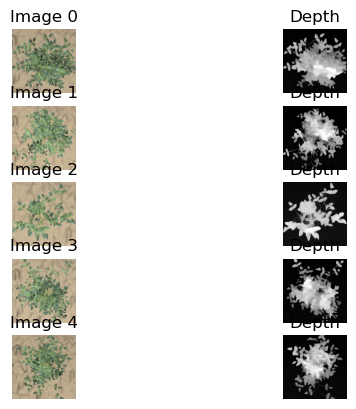

In [4]:
# Show some images
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# train_dataset = PlantDataset("../_data/Syn2Real_cowpea/Syn2Real_cowpea", plot=["000", "001", "002", "003"], transform=transform,dry_run=True,use_depth=False)

import cv2
n = 5
for i in range(n):
    image, vecs, _ = train_dataset[-i-1]
    image = image.permute(1, 2, 0)
    image_rgb = image[:, :, :3]
    img = cv2.normalize(np.array(image_rgb.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(img)
    plt.title(f"Image {i}")
    plt.axis('off')

    if train_dataset.use_depth:
        image_depth = image[:, :, 3]
        img = cv2.normalize(np.array(image_depth.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        plt.subplot(5, 2, 2*i+2)
        plt.imshow(img, cmap='gray')
        plt.title("Depth")
        plt.axis('off')

In [5]:
from models.model import ImageToSequenceTransformer


# Initialize model
num_layers =  3 # Default 6
num_heads = 4   # Default 8 
seq_dim = 43 # 43개의 토큰 
seq_embedding_dim = 64 # 
param_dim = 5 + 3 + 2 + 4
param_embedding_dim = 64

model = ImageToSequenceTransformer(seq_embedding_dim=seq_embedding_dim, 
                                   param_embedding_dim=param_embedding_dim,
                                   num_layers=num_layers, num_heads=num_heads, 
                                   num_tokens=seq_dim, num_params=param_dim,
                                   decoder_only=True,
                                   use_depth=True)
# Test model
if 0:
    image_paths, vectors, lengths = next(iter(train_dataloader))
    output = model(image_paths, vectors)
model = model.to(device)
print(model)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
labes_loss_fn = nn.CrossEntropyLoss()

num_epochs = 20
model.to(device)

/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImageToSequenceTransformer(
  (cnn): CNN_ViT(
    (model): ViTModel(
      (embeddings): ViTEmbeddings(
        (patch_embeddings): ViTPatchEmbeddings(
          (projection): Conv2d(4, 768, kernel_size=(16, 16), stride=(16, 16))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): ViTEncoder(
        (layer): ModuleList(
          (0-11): 12 x ViTLayer(
            (attention): ViTSdpaAttention(
              (attention): ViTSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): ViTSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )
           

ImageToSequenceTransformer(
  (cnn): CNN_ViT(
    (model): ViTModel(
      (embeddings): ViTEmbeddings(
        (patch_embeddings): ViTPatchEmbeddings(
          (projection): Conv2d(4, 768, kernel_size=(16, 16), stride=(16, 16))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): ViTEncoder(
        (layer): ModuleList(
          (0-11): 12 x ViTLayer(
            (attention): ViTSdpaAttention(
              (attention): ViTSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): ViTSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
            )
           

In [6]:
def collate_fn(batch):
    images, vectors, lengths = zip(*batch)
    max_length = max(lengths)
    # Check if the vectors are 1 dimensional
    if len(vectors[0].shape) == 1:
        vectors_padded = np.ones((len(vectors), max_length), dtype=int) * PAD_token
    else:
        vectors_padded = np.ones((len(vectors), max_length, 1+5+3+2+4)) * PAD_token
        if 0:
            # Reset param space
            vectors_padded[:,:,1:] = 0
        
    for i, vector in enumerate(vectors):
        end = lengths[i]
        vectors_padded[i, :end] = vector
    images = torch.stack(images)
    vectors_padded = torch.tensor(vectors_padded,dtype=torch.float32)
    return images, vectors_padded, lengths

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
gen_dataloader = DataLoader(val_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

In [7]:
train_loss_list, validation_loss_list = [], []
pretrained = True
#model_save_path = '../models/checkpoints/ViT_Transformer_rgbd_params_est_param_20240703.pth'
model_save_path = '../models/checkpoints/ViT_Transformer_rgbd_params_est_param.pth'
if pretrained:
    model.load_state_dict(torch.load(model_save_path))

/tmp/ipykernel_3661885/2000270604.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out = torch.tensor(out).to(device)


Example 0
Input Structure: [[ 0.00000000e+00  0.00000000e+00  2.88154305e+00  6.72431236e+01
   8.47615411e+01  1.00000000e+02  1.00000000e+00]
 [ 1.00000000e+00  1.00000000e+00  2.00000000e-02  5.00000007e-04
   0.00000000e+00  1.37500000e+02  0.00000000e+00]
 [ 1.00000000e+00  2.00000000e+00  7.50000000e-03  5.00000000e-04
   7.15883533e+01  0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  3.00000000e+00  2.00000000e-02  6.49327515e+00
   0.00000000e+00 -2.63807604e+00  0.00000000e+00]
 [ 1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   9.00000025e+01  1.00000000e+02  3.00000000e+00]
 [ 2.00000000e+00  1.00000000e+00  1.20000005e-02  1.00000001e-03
   1.99999994e+01  1.37500000e+02  0.00000000e+00]
 [ 2.00000000e+00  2.00000000e+00  1.05831003e-01  5.00000000e-04
   5.23422053e+01  0.00000000e+00  0.00000000e+00]
 [ 2.00000000e+00  3.00000000e+00  4.02209997e-02  9.70190464e+00
   0.00000000e+00  3.79217610e+00  0.00000000e+00]
 [ 2.00000000e+00  1.00000000e+00  1.

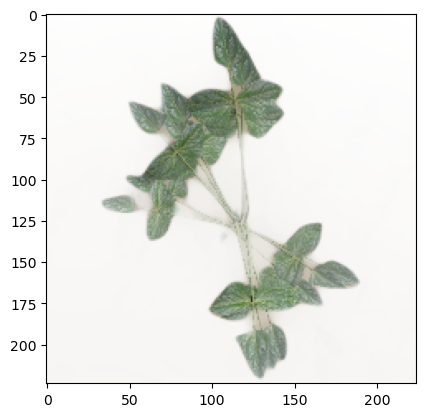

In [8]:
from plant_tokenizer import params_SOS_token_padded, SOS_token, EOS_token, token2vec
from utils import get_tgt_mask

def plot_image(image):
    # Plot the image
    image_vis = image.permute(0, 2, 3, 1).cpu().numpy()
    img_rgb = image_vis[0, :, :, :3]
    img_depth = image_vis[0, :, :, 3]
    # Normalize img_rgb to 0-255 per channels
    for i in range(3):
        img_rgb[:, :, i] = (img_rgb[:, :, i] - img_rgb[:, :, i].min()) / (img_rgb[:, :, i].max() - img_rgb[:, :, i].min()) * 255
    img_rgb = img_rgb.astype(np.uint8)
    # BGR to RGB
    # img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 10))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.subplot(1, 2, 2)
    plt.imshow(img_depth)
    plt.show()


def predict(model, images, out, max_length=15, SOS_token=2, EOS_token=3):
    # Assuming 'device' is defined elsewhere in your code and is a CUDA device.
    y_input = torch.tensor(params_SOS_token_padded, dtype=torch.float32)
    
    # Change to 1,1,15
    y_input = y_input.unsqueeze(0).unsqueeze(0)
    y_input = y_input.to(device)
    for i in range(max_length):
        # Get source mask
        tgt_mask = get_tgt_mask(y_input.size(1)).to(device)
        
        try:
            with torch.no_grad():
                pred = model(images, y_input, tgt_mask)
        except Exception as e:
            print(e)
            print(f"Error in {i} iteration")
            break
        label_p = pred[:,:,:seq_dim]
        label = label_p.topk(1)[1].view(-1)[-1].item()  # num with highest probability
        params = pred[:,:,seq_dim:]

        # Stop if model predicts end of sentencplant_structure_vit_transformer_withpsudodepth_paramEste
        if label == EOS_token or label == PAD_token:
            break

        # Make next tensor using label and params
        next_item = torch.cat((torch.tensor([[label]], dtype=torch.float32, device=device), params[-1]), dim=1).unsqueeze(0)

        # Concatenate previous input with predicted best word
        y_input = torch.cat((y_input, next_item), dim=1)

    return y_input.squeeze(0).tolist()

model.eval()
for idx, (image, out, lengths) in enumerate(gen_dataloader):
    out = torch.tensor(out).to(device)
    image_paths = image.to(device)

    # Plot the image
    # Draw the image
    image_vis = image.squeeze(0).permute(1,2,0).cpu().numpy()
    img = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    image_vis = img.astype(np.uint8)
    plt.imshow(image_vis)
    result = predict(model, image_paths, out, max_length=2048, SOS_token=SOS_token, EOS_token=EOS_token)
    print(f"Example {idx}")
    print(f"Input Structure: {token2vec(out.squeeze(0).tolist())}")
    print(f"Input Token: {out.squeeze(0).tolist()}")
    print(f"Continuation Token: {result}")
    print(f"Continuation Structure: {token2vec(result)}")
    print()
    break